# Disaster Event Analysis using NLP and Prompt Engineering

## Section 1: Assignment Information

**Course Name:** Natural Language Processing  
**Problem Statement Number:** PS1  
**Assignment Title:** Disaster Event Analysis using NLP and Prompt Engineering  
**Group Number:** Group-33  

### Team Member Details

| S.No | Team Members | BITS ID | Contribution Percentage |
|---|---|---|---|
| 1 | Siv Ram S | 2024DC04173 | 100% |
| 2 | Sobana S | 2024DC04174 | 100% |
| 3 | Ragavan M | 2024DC04175 | 100% |
| 4 | Patil Shweta Sanjayrao | 2024DC04177 | 100% |

### Contribution Summary

The implementation includes dataset loading, preprocessing, NLP analysis, word embedding generation, sentiment classification, prompt engineering based information extraction, evaluation and discussion.

## Section 2: Problem Statement

### Assigned Problem Statement

During natural disasters such as floods, earthquakes and cyclones, authorities need to analyze social media posts to understand public sentiment and identify emergency needs.

The task is to develop an NLP-based system that analyzes disaster-related social media posts. The system should perform sentiment analysis and extract useful information such as disaster type, location and emergency requirements.

### Objective of the Assignment

The objective of this assignment is to apply Natural Language Processing (NLP) techniques to disaster-related social media posts. The project involves data preprocessing, word embedding analysis, sentiment classification and prompt engineering to extract useful information from the posts.

## Section 3: Dataset Description

### Dataset Selected

The dataset used in this assignment is the **Disaster Tweets** dataset. It contains disaster-related social media posts and supporting fields such as keyword, location, tweet text and target label.

### Dataset Source

- **Dataset Name:** Disaster Tweets
- **Source Platform:** Kaggle
- **Dataset File Used:** tweets.csv
- **Main Text Column:** text
- **Supporting Columns:** keyword, location, target

### Dataset Link : https://www.kaggle.com/datasets/vstepanenko/disaster-tweets/versions/2/data

### Dataset Statistics

The selected dataset contains:

- **Number of Records:** 11,370
- **Number of Columns:** 5

Additional dataset information such as vocabulary size, column names, missing values and sample records is displayed in the following cell.

### Environment Setup and Library Imports

This cell imports the libraries required for the complete NLP workflow. The libraries are grouped based on their purpose:

- Data handling
- Text cleaning
- Visualization
- NLP preprocessing
- Sentiment analysis
- Machine learning
- Word embedding generation

In [6]:

# Environment Setup and Library Imports

# Basic data handling libraries
import pandas as pd
import numpy as np

# Text cleaning and regular expressions
import re
import string
from collections import Counter

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK libraries for NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# Sentiment analysis using VADER
from nltk.sentiment import SentimentIntensityAnalyzer

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Word embedding model
from gensim.models import Word2Vec

# Display settings for cleaner notebook output
pd.set_option("display.max_colwidth", 120)
sns.set_context("notebook")

print("All required libraries imported successfully.")


All required libraries imported successfully.


### Downloading Required NLTK Resources

In [8]:
# ============================================================
# Section 3.3: Downloading Required NLTK Resources
# ============================================================

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("vader_lexicon")


import nltk
from nltk import pos_tag

# Download the required POS tagger
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_dat

In [9]:

# Loading tweets.csv Dataset

dataset_file = "tweets.csv"

df = pd.read_csv(dataset_file)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully.
Dataset shape: (11370, 5)


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were se...",1
1,1,ablaze,NaN,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on ...",1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l…...",0


### Section 3.1 Dataset Statistics

The following dataset statistics are displayed in the next code cell:

- Number of records (posts)
- Number of columns
- Vocabulary size
- Column names
- Missing values in each column
- Sample records from the dataset
- Verification that the dataset contains at least 5,000 posts

In [11]:

# Section 3.1: Dataset Statistics

# Check that the required text column exists
if "text" not in df.columns:
    raise ValueError("The dataset must contain a 'text' column.")

# Create a working copy
data = df.copy()

# Remove rows with missing text
data = data.dropna(subset=["text"]).reset_index(drop=True)

# Convert text column to string
data["text"] = data["text"].astype(str)

# Calculate vocabulary size
vocabulary = set(" ".join(data["text"]).lower().split())
vocab_size = len(vocabulary)

print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)

print(f"Number of Records(Posts) : {len(data)}")
print(f"Vocabulary Size   : {vocab_size}")

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nFirst 5 Records:")
display(data.head())

if len(data) >= 5000:
    print("\n✓ Requirement satisfied: Dataset contains at least 5,000 posts.")
else:
    print("\n✗ Requirement not satisfied: Dataset contains fewer than 5,000 posts.")

DATASET STATISTICS
Number of Records(Posts) : 11370
Vocabulary Size   : 40016

Column Names:
['id', 'keyword', 'location', 'text', 'target']

Data Types:
id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

Missing Values:
id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

First 5 Records:


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were se...",1
1,1,ablaze,NaN,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on ...",1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l…...",0



✓ Requirement satisfied: Dataset contains at least 5,000 posts.


## 3.2 Raw Vocabulary Size Before Preprocessing

Vocabulary size refers to the number of unique words present in the dataset. At this stage, the raw vocabulary is calculated before preprocessing.

This raw vocabulary may contain noisy tokens such as punctuation, URLs, mentions and different word forms. A cleaner vocabulary will be calculated again after preprocessing.

In [13]:

# Section 3.2: Raw Vocabulary Size Before Preprocessing

all_raw_words = []

for text in data["text"]:
    words = str(text).lower().split()
    all_raw_words.extend(words)

raw_vocabulary = set(all_raw_words)

print("Total raw word count:", len(all_raw_words))
print("Raw vocabulary size before preprocessing:", len(raw_vocabulary))

Total raw word count: 195179
Raw vocabulary size before preprocessing: 40016


# Section 4: Data Preprocessing

The collected social media posts contain noisy text such as URLs, user mentions, hashtags, punctuation and inconsistent letter casing. Therefore, preprocessing is performed before applying NLP techniques.

The following preprocessing steps are carried out:

1. Convert text to lowercase
2. Remove URLs and user mentions
3. Remove hashtag symbols while keeping the hashtag words
4. Remove punctuation, numbers and special characters
5. Tokenize the text into words
6. Remove English stop words
7. Perform lemmatization

The processed text is used in the later tasks such as word frequency analysis, POS tagging, word embeddings and sentiment classification.

### 4.1 Text Cleaning and Preprocessing

In this step, two functions are created:

- **`clean_text()`** cleans the raw tweet by removing unwanted characters and formatting.
- **`preprocess_text()`** performs tokenization, stop-word removal and lemmatization.

The processed words are stored as tokens as well as a processed text string for further analysis.

In [16]:

# Section 4.1: Text Cleaning and Preprocessing Functions


# Initialize stop words and lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Cleans raw social media text by removing noisy elements such as
    URLs, mentions, punctuation, numbers and extra spaces.
    """
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove user mentions such as @username
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtag symbol but keep the hashtag word
    text = re.sub(r"#", "", text)

    # Remove HTML entities such as &amp;
    text = re.sub(r"&\w+;", " ", text)

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_text(text):
    """
    Performs tokenization, stop-word removal and lemmatization.
    """
    cleaned = clean_text(text)

    # Tokenization
    tokens = word_tokenize(cleaned)

    # Stop-word removal and removal of very short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

print("Text cleaning and preprocessing functions are ready.")


Text cleaning and preprocessing functions are ready.


### 4.2 Applying Text Preprocessing

The preprocessing functions are now applied to every tweet in the dataset.

Three new columns are created:

- `clean_text`: cleaned version of the original tweet
- `tokens`: list of cleaned and lemmatized words
- `processed_text`: final processed text created by joining the tokens

In [18]:

# Section 4.2: Applying Text Preprocessing

data["clean_text"] = data["text"].apply(clean_text)
data["tokens"] = data["text"].apply(preprocess_text)
data["processed_text"] = data["tokens"].apply(lambda tokens: " ".join(tokens))

print("Text preprocessing completed successfully.")

data[["text", "clean_text", "tokens", "processed_text"]].head()

Text preprocessing completed successfully.


,text,clean_text,tokens,processed_text
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were se...",communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ab...,"[communal, violence, bhainsa, telangana, stone, pelted, muslim, house, house, vehicle, set, ablaze]",communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on ...",telangana section has been imposed in bhainsa from january to after clash erupted between two groups on january po,"[telangana, section, imposed, bhainsa, january, clash, erupted, two, group, january]",telangana section imposed bhainsa january clash erupted two group january
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,arsonist sets cars ablaze at dealership,"[arsonist, set, car, ablaze, dealership]",arsonist set car ablaze dealership
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,arsonist sets cars ablaze at dealership,"[arsonist, set, car, ablaze, dealership]",arsonist set car ablaze dealership
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l…...",lord jesus your love brings freedom and pardon fill me with your holy spirit and set my heart ablaze with your l,"[lord, jesus, love, brings, freedom, pardon, fill, holy, spirit, set, heart, ablaze]",lord jesus love brings freedom pardon fill holy spirit set heart ablaze


### 4.3 Preprocessing Examples

The table below shows five examples of original tweet text and the corresponding processed text.

This output helps verify that preprocessing has been applied correctly.

In [20]:

# Displaying Preprocessing Examples


preprocessing_examples = data[["text", "processed_text"]].head(5).copy()
preprocessing_examples.columns = ["Sample Input data", "Preprocessed Output"]

preprocessing_examples

,Sample Input data,Preprocessed Output
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were se...",communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on ...",telangana section imposed bhainsa january clash erupted two group january
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,arsonist set car ablaze dealership
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,arsonist set car ablaze dealership
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l…...",lord jesus love brings freedom pardon fill holy spirit set heart ablaze


### 4.4 Vocabulary Size After Preprocessing

Vocabulary size is calculated again after preprocessing.

The processed vocabulary is expected to be cleaner than the raw vocabulary because

In [22]:

# Vocabulary Size After Preprocessing


all_processed_words = []

for tokens in data["tokens"]:
    all_processed_words.extend(tokens)

processed_vocabulary = set(all_processed_words)

print("Total processed word count:", len(all_processed_words))
print("Processed vocabulary size after preprocessing:", len(processed_vocabulary))

Total processed word count: 103111
Processed vocabulary size after preprocessing: 18365


## Section 5: Task-wise Implementation

This section contains the task-wise implementation for the assigned problem statement. Each task includes a task description, implementation, output and observation.

The first task focuses on data collection and preprocessing outputs. Since the dataset has already been loaded and preprocessed, this section displays the required analysis outputs such as frequent words and POS tagging results.

## Section 5.1: Task 1 - Data Collection and Preprocessing

### Task Description

The objective of this task is to preprocess the disaster-related social media posts before applying NLP techniques. The selected dataset contains more than **5,000** posts, satisfying the assignment requirement.

The following preprocessing steps are performed:

- Tokenization
- Stop-word removal
- Lemmatization
- POS tagging

### Required Outputs

This task also requires the following outputs:

- Top 20 most frequent words
- POS tag distribution


### 5.1.1 Verification of Dataset Size and Preprocessing Columns

Before generating Task 1 outputs, the dataset size and preprocessing columns are verified. This ensures that the dataset satisfies the minimum requirement and that the required processed columns are available.


In [26]:

# Verification of Dataset and Preprocessing


print("=" * 60)
print("TASK 1: DATASET VERIFICATION")
print("=" * 60)

# Verify dataset size
num_posts = len(data)

print(f"Number of Posts : {num_posts}")

if num_posts >= 5000:
    print("✓ Requirement satisfied: Dataset contains at least 5,000 posts.")
else:
    print("✗ Requirement not satisfied: Dataset contains fewer than 5,000 posts.")

# Verify preprocessing columns
required_columns = ["text", "clean_text", "tokens", "processed_text"]

print("\nPreprocessing Columns:")

for col in required_columns:
    if col in data.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ {col} (Missing)")

# Display sample records
print("\nSample Preprocessed Records:")
display(data[required_columns].head())

TASK 1: DATASET VERIFICATION
Number of Posts : 11370
✓ Requirement satisfied: Dataset contains at least 5,000 posts.

Preprocessing Columns:
✓ text
✓ clean_text
✓ tokens
✓ processed_text

Sample Preprocessed Records:


,text,clean_text,tokens,processed_text
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were se...",communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ab...,"[communal, violence, bhainsa, telangana, stone, pelted, muslim, house, house, vehicle, set, ablaze]",communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on ...",telangana section has been imposed in bhainsa from january to after clash erupted between two groups on january po,"[telangana, section, imposed, bhainsa, january, clash, erupted, two, group, january]",telangana section imposed bhainsa january clash erupted two group january
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,arsonist sets cars ablaze at dealership,"[arsonist, set, car, ablaze, dealership]",arsonist set car ablaze dealership
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,arsonist sets cars ablaze at dealership,"[arsonist, set, car, ablaze, dealership]",arsonist set car ablaze dealership
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l…...",lord jesus your love brings freedom and pardon fill me with your holy spirit and set my heart ablaze with your l,"[lord, jesus, love, brings, freedom, pardon, fill, holy, spirit, set, heart, ablaze]",lord jesus love brings freedom pardon fill holy spirit set heart ablaze


### 5.1.2 POS Tagging

Part-of-Speech tagging assigns grammatical labels to words. For example:

- Nouns may represent disaster types, locations, objects or resources.
- Verbs may represent actions such as rescue, evacuate, help or need.
- Adjectives may describe severity, damage or urgency.

POS tagging is useful in disaster analysis because it helps understand the linguistic structure of social media posts.

In [28]:

# POS Tagging

# Apply POS tagging to the preprocessed tokens
data["pos_tags"] = data["tokens"].apply(lambda tokens: pos_tag(tokens))

print("POS tagging completed successfully.")

data[["processed_text", "pos_tags"]].head()

POS tagging completed successfully.


,processed_text,pos_tags
0,communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze,"[(communal, JJ), (violence, NN), (bhainsa, NN), (telangana, NN), (stone, NN), (pelted, VBD), (muslim, JJ), (house, N..."
1,telangana section imposed bhainsa january clash erupted two group january,"[(telangana, JJ), (section, NN), (imposed, VBN), (bhainsa, IN), (january, JJ), (clash, NN), (erupted, VBD), (two, CD..."
2,arsonist set car ablaze dealership,"[(arsonist, NN), (set, NN), (car, NN), (ablaze, NN), (dealership, NN)]"
3,arsonist set car ablaze dealership,"[(arsonist, NN), (set, NN), (car, NN), (ablaze, NN), (dealership, NN)]"
4,lord jesus love brings freedom pardon fill holy spirit set heart ablaze,"[(lord, NN), (jesus, NN), (love, VBP), (brings, NNS), (freedom, NN), (pardon, NN), (fill, NN), (holy, JJ), (spirit, ..."


### 5.1.3 POS-tagged Sentence Examples

The following output shows five examples of processed tweets along with their POS tags. This verifies that POS tagging has been applied successfully.

In [30]:

# POS-tagged Sentence Examples

pos_examples = data[["processed_text", "pos_tags"]].head(5).copy()

pos_examples

,processed_text,pos_tags
0,communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze,"[(communal, JJ), (violence, NN), (bhainsa, NN), (telangana, NN), (stone, NN), (pelted, VBD), (muslim, JJ), (house, N..."
1,telangana section imposed bhainsa january clash erupted two group january,"[(telangana, JJ), (section, NN), (imposed, VBN), (bhainsa, IN), (january, JJ), (clash, NN), (erupted, VBD), (two, CD..."
2,arsonist set car ablaze dealership,"[(arsonist, NN), (set, NN), (car, NN), (ablaze, NN), (dealership, NN)]"
3,arsonist set car ablaze dealership,"[(arsonist, NN), (set, NN), (car, NN), (ablaze, NN), (dealership, NN)]"
4,lord jesus love brings freedom pardon fill holy spirit set heart ablaze,"[(lord, NN), (jesus, NN), (love, VBP), (brings, NNS), (freedom, NN), (pardon, NN), (fill, NN), (holy, JJ), (spirit, ..."


### 5.1.4 Top 20 Frequent Words

The top 20 frequent words are calculated from the preprocessed tokens. This helps identify the most commonly used terms in the disaster-related social media posts.

Since stop words and noisy tokens have already been removed, the frequent words are more meaningful for disaster event analysis.


In [32]:

# Top 20 Frequent Words
from collections import Counter

# Count word frequencies from all processed tokens
word_frequency = Counter(all_processed_words)

# Extract the top 20 most frequent words
top_20_words = word_frequency.most_common(20)

# Convert results into a DataFrame for display
top_20_df = pd.DataFrame(top_20_words, columns=["Word", "Frequency"])

top_20_df


,Word,Frequency
0,like,549
1,people,539
2,fire,492
3,one,449
4,get,369
5,year,363
6,time,307
7,need,291
8,day,284
9,new,277


### Observation for Top 20 Frequent Words

The frequent word output provides an overview of the most common terms appearing in the disaster-related posts. These words may include disaster events, impact-related terms, emergency words or commonly discussed topics.

This output is useful for understanding the major themes in the dataset and for selecting disaster-related terms in the word embedding analysis.

### 5.1.5 POS Tag Distribution

The POS tag distribution counts how often each POS tag appears in the processed dataset. This helps identify the most common grammatical categories in the disaster-related posts.
``

In [35]:

# POS Tag Distribution Table


all_pos_tags = []

for tagged_sentence in data["pos_tags"]:
    for word, tag in tagged_sentence:
        all_pos_tags.append(tag)

pos_distribution = Counter(all_pos_tags)

pos_distribution_df = pd.DataFrame(
    pos_distribution.items(),
    columns=["POS Tag", "Frequency"]
).sort_values(by="Frequency", ascending=False)

pos_distribution_df.head(20)

,POS Tag,Frequency
1,NN,52796
0,JJ,17926
2,VBD,5307
10,RB,5045
13,VBG,4943
6,VBP,2896
9,VB,2798
7,NNS,2760
3,VBN,2458
4,IN,2023


### 5.1.6 Visualization of POS Tag Distribution

The chart below shows the top POS tags based on frequency. It gives a visual understanding of the grammatical structure of the disaster-related tweets.

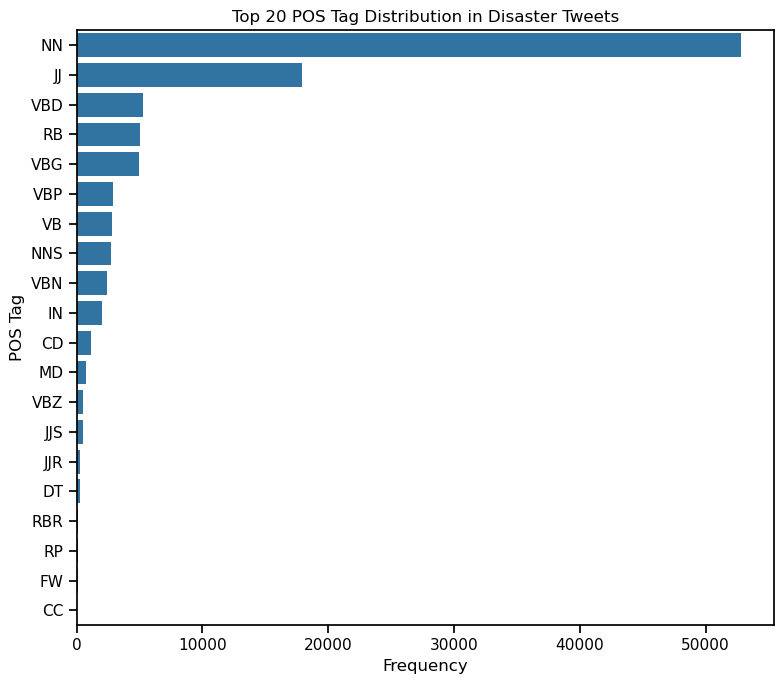

In [37]:

# Visualization of POS Tag Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 7))
sns.barplot(data=pos_distribution_df.head(20), x="Frequency", y="POS Tag")
plt.title("Top 20 POS Tag Distribution in Disaster Tweets")
plt.xlabel("Frequency")
plt.ylabel("POS Tag")
plt.tight_layout()
plt.show()

### Observation for POS Tag Distribution

The POS tag distribution shows the frequency of grammatical categories in the processed tweets. If noun-related tags appear frequently, it suggests that the dataset contains many entity-like terms such as disaster names, places, objects or emergency resources. Verb-related tags indicate action-oriented posts, which may describe rescue, damage, warning or emergency needs.

This analysis supports the disaster event analysis task by giving insight into the language patterns used in social media posts during disaster-related discussions.

## Section 5.2: Task 2 - Word Embedding Analysis

### Task Description

Task 2 requires generating word embeddings using either Word2Vec or GloVe. In this notebook, Word2Vec is used because it can learn vector representations of words directly from the disaster tweet dataset.

Word embeddings represent words as numerical vectors. Words that appear in similar contexts usually have embeddings that are closer to each other in the vector space.

### Method Used

- **Embedding Method:** Word2Vec
- **Architecture:** Skip-Gram
- **Input Data:** Preprocessed tweet tokens
- **Purpose:** To identify semantically similar disaster-related words

### 5.2.1 Preparing Sentences for Word2Vec

Word2Vec requires input as a list of tokenized sentences. Since the `tokens` column already contains preprocessed tokens for each tweet, it can be directly used for training the Word2Vec model.

Empty token lists are removed to avoid training issues.

In [41]:

# Preparing Sentences for Word2Vec


# Word2Vec expects a list of token lists.
# Each tweet is treated as one sentence/document.
word2vec_sentences = data["tokens"].tolist()

# Remove empty token lists if any
word2vec_sentences = [tokens for tokens in word2vec_sentences if len(tokens) > 0]

print("Number of tokenized sentences used for Word2Vec training:", len(word2vec_sentences))
print("Example tokenized sentence:")
print(word2vec_sentences[0])

Number of tokenized sentences used for Word2Vec training: 11363
Example tokenized sentence:
['communal', 'violence', 'bhainsa', 'telangana', 'stone', 'pelted', 'muslim', 'house', 'house', 'vehicle', 'set', 'ablaze']


### 5.2.2 Training the Word2Vec Model

The Word2Vec model is trained using the Skip-Gram architecture. Word2Vec learns numerical vector representations of words based on the context in which words appear.

The parameters used are:

- `vector_size = 100`: Each word is represented using a 100-dimensional vector.
- `window = 5`: Five neighboring words are considered as context.
- `min_count = 2`: Words appearing fewer than two times are ignored.
- `sg = 1`: Skip-Gram architecture is used.
- `epochs = 20`: The model is trained for 20 iterations.
- `workers = 4`: Four CPU workers are used for faster training.

In [43]:
!pip install gensim

In [44]:

# Training Word2Vec Model

from gensim.models import Word2Vec
vector_size = 100
window_size = 5
min_word_count = 2
skip_gram = 1
epochs = 20
workers = 4

word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=vector_size,
    window=window_size,
    min_count=min_word_count,
    sg=skip_gram,
    workers=workers,
    epochs=epochs,
    seed=42
)

print("Word2Vec model training completed successfully.")

Word2Vec model training completed successfully.


### 5.2.3 Displaying Word2Vec Training Parameters

The training parameters are displayed in a table so that the model configuration is clearly documented in the notebook and can be used in the report.

In [46]:

# Word2Vec Training Parameters


word2vec_parameters = pd.DataFrame({
    "Parameter": [
        "Embedding Method",
        "Model Architecture",
        "Vector Dimension",
        "Window Size",
        "Minimum Word Frequency",
        "Epochs",
        "Workers",
        "Random Seed"
    ],
    "Value": [
        "Word2Vec",
        "Skip-Gram",
        vector_size,
        window_size,
        min_word_count,
        epochs,
        workers,
        42
    ]
})

word2vec_parameters

,Parameter,Value
0,Embedding Method,Word2Vec
1,Model Architecture,Skip-Gram
2,Vector Dimension,100
3,Window Size,5
4,Minimum Word Frequency,2
5,Epochs,20
6,Workers,4
7,Random Seed,42


### 5.2.4 Word2Vec Vocabulary Size

The Word2Vec vocabulary contains the words learned by the model after applying the minimum frequency condition. Words appearing fewer than two times are not included in the Word2Vec vocabulary.

In [48]:

# Word2Vec Vocabulary Size


word2vec_vocab = list(word2vec_model.wv.index_to_key)

print("Word2Vec vocabulary size:", len(word2vec_vocab))
print("First 20 words in Word2Vec vocabulary:")
print(word2vec_vocab[:20])

Word2Vec vocabulary size: 8569
First 20 words in Word2Vec vocabulary:
['like', 'people', 'fire', 'one', 'get', 'year', 'time', 'need', 'day', 'new', 'would', 'know', 'say', 'iran', 'first', 'see', 'today', 'storm', 'think', 'death']


### 5.2.5 Displaying a Sample Embedding Vector

Each word in the Word2Vec vocabulary is represented as a numerical vector. The example below displays one sample word and the first 20 values of its embedding vector.

Only the first 20 values are shown to keep the notebook output readable.

In [50]:

# Displaying Sample Embedding Vector


sample_word = word2vec_vocab[0]
sample_vector = word2vec_model.wv[sample_word]

print("Sample word:", sample_word)
print("Embedding vector dimension:", sample_vector.shape)
print("First 20 values of the embedding vector:")
print(sample_vector[:20])

Sample word: like
Embedding vector dimension: (100,)
First 20 values of the embedding vector:
[ 0.181612    0.41804594  0.09042107  0.1282589  -0.24738649  0.20447016
 -0.40694383  0.10454848 -0.01090761 -0.37509033 -0.74641746  0.4641039
  0.28843376  0.7590821  -0.0315401   0.6530705   0.08073165 -0.5374692
  0.38983113 -0.47150272]


### 5.2.6 Selecting Top 10 Disaster-related Terms

Important disaster-related terms are selected for similarity analysis. These words are chosen because they are commonly associated with disasters, emergency response, damage and public safety.

Only words available in the trained Word2Vec vocabulary are selected. If some predefined disaster terms are not available in the vocabulary, the code automatically fills the remaining positions using frequent words from the Word2Vec vocabulary.

In [52]:

# Selecting Top 10 Disaster-related Terms


candidate_disaster_terms = [
    "fire",
    "flood",
    "earthquake",
    "storm",
    "cyclone",
    "evacuation",
    "rescue",
    "damage",
    "emergency",
    "disaster",
    "wildfire",
    "hurricane",
    "tsunami",
    "injured",
    "warning",
    "collapse",
    "death",
    "crash",
    "rain",
    "help"
]

selected_terms = []

for term in candidate_disaster_terms:
    if term in word2vec_model.wv:
        selected_terms.append(term)

if len(selected_terms) < 10:
    for word in word2vec_vocab:
        if word not in selected_terms:
            selected_terms.append(word)
        if len(selected_terms) == 10:
            break

selected_terms = selected_terms[:10]

print("Top 10 selected disaster-related terms:")
print(selected_terms)

Top 10 selected disaster-related terms:
['fire', 'flood', 'earthquake', 'storm', 'cyclone', 'evacuation', 'rescue', 'damage', 'emergency', 'disaster']


### 5.2.7 Top 5 Similar Words for Each Selected Term

For each selected disaster-related term, the Word2Vec model identifies the top 5 most similar words. Similarity is calculated based on the closeness of word vectors in the embedding space.

This output helps understand whether the model has learned meaningful relationships between disaster-related words.

In [54]:
# Top 5 Similar Words


compact_similar_words = []

for term in selected_terms:
    top_similar_words = word2vec_model.wv.most_similar(term, topn=5)

    similar_word_list = []

    for word, score in top_similar_words:
        similar_word_list.append(word + " (" + str(round(score, 3)) + ")")

    compact_result = {
        "Target Disaster Term": term,
        "Top 5 Similar Words": ", ".join(similar_word_list)
    }

    compact_similar_words.append(compact_result)

compact_similar_words_df = pd.DataFrame(compact_similar_words)
pd.set_option("display.max_colwidth", None)
compact_similar_words_df

,Target Disaster Term,Top 5 Similar Words
0,fire,"forest (0.671), bush (0.669), planner (0.536), bezos (0.533), wild (0.533)"
1,flood,"areal (0.679), advisory (0.673), meg (0.656), mapping (0.655), alcorn (0.653)"
2,earthquake,"rico (0.873), puerto (0.858), ponce (0.853), barrio (0.852), canas (0.85)"
3,storm,"brendan (0.818), dust (0.791), violent (0.767), surge (0.73), monster (0.728)"
4,cyclone,"claudia (0.885), rockall (0.881), southwesterly (0.863), flovilla (0.862), smith (0.86)"
5,evacuation,"center (0.857), leni (0.855), dire (0.852), batangas (0.836), evacuee (0.834)"
6,rescue,"scaniatrucks (0.739), helicopte (0.719), operation (0.707), virgin (0.698), ethekwini (0.692)"
7,damage,"unite (0.636), degrano (0.63), imjin (0.621), mwah (0.61), mp (0.605)"
8,emergency,"industrial (0.67), medical (0.657), radiation (0.642), netcare (0.636), gauteng (0.633)"
9,disaster,"synonymous (0.75), olympics (0.746), tokyo (0.697), coded (0.691), fukushima (0.688)"


### 5.2.8 Similar Words Analysis

In [56]:

 ## Similar Word Analysis


analysis = []

for term in selected_terms:
    similar_words = word2vec_model.wv.most_similar(term, topn=5)

    avg_similarity = sum(score for _, score in similar_words) / len(similar_words)

    analysis.append({
        "Disaster Term": term,
        "Average Similarity": round(avg_similarity, 3),
        "Most Similar Word": similar_words[0][0]
    })

analysis_df = pd.DataFrame(analysis)

print("Analysis of Similar Words:")
display(analysis_df)

Analysis of Similar Words:


,Disaster Term,Average Similarity,Most Similar Word
0,fire,0.589,forest
1,flood,0.663,areal
2,earthquake,0.857,rico
3,storm,0.767,brendan
4,cyclone,0.870,claudia
5,evacuation,0.847,center
6,rescue,0.711,scaniatrucks
7,damage,0.621,unite
8,emergency,0.648,industrial
9,disaster,0.714,synonymous


### Visualization of Selected Disaster Term Frequencies

The chart below visualizes the frequency of selected disaster-related terms.

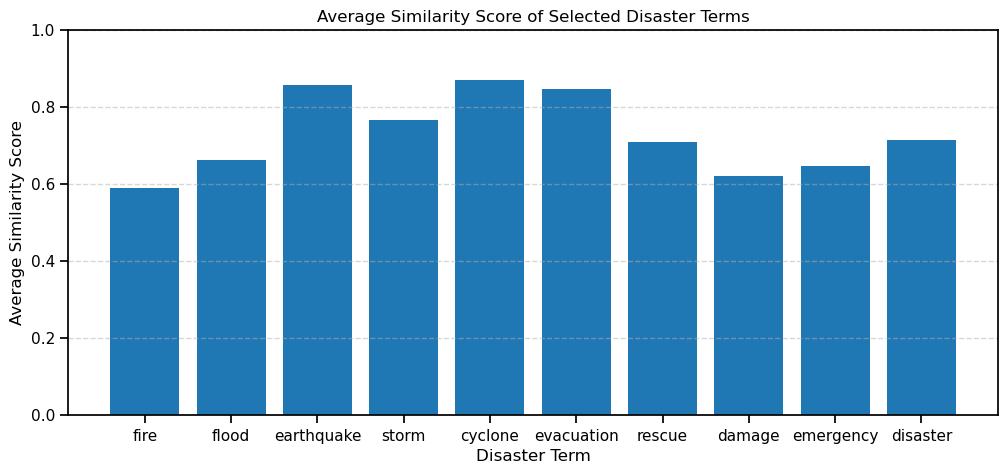

In [58]:

# Average Similarity Scores


plt.figure(figsize=(12,5))

plt.bar(
    analysis_df["Disaster Term"],
    analysis_df["Average Similarity"]
)

plt.title("Average Similarity Score of Selected Disaster Terms")
plt.xlabel("Disaster Term")
plt.ylabel("Average Similarity Score")

plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### 5.2.9 Frequency of Selected Disaster-related Terms

The frequency of the selected disaster-related terms is displayed to show how often these terms appear in the processed dataset.

In [60]:

#  Frequency of Selected Disaster Terms

selected_term_frequencies = []

for term in selected_terms:
    term_frequency = word_frequency.get(term, 0)

    selected_term_frequencies.append({
        "Term": term,
        "Frequency": term_frequency
    })

selected_term_freq_df = pd.DataFrame(selected_term_frequencies)

selected_term_freq_df = selected_term_freq_df.sort_values(
    by="Frequency",
    ascending=False
)

selected_term_freq_df

,Term,Frequency
0,fire,492
3,storm,208
8,emergency,194
9,disaster,120
1,flood,111
2,earthquake,86
6,rescue,85
7,damage,71
5,evacuation,31
4,cyclone,17


### Visualization of Selected Disaster Term Frequencies

The chart below visualizes the frequency of selected disaster-related terms.

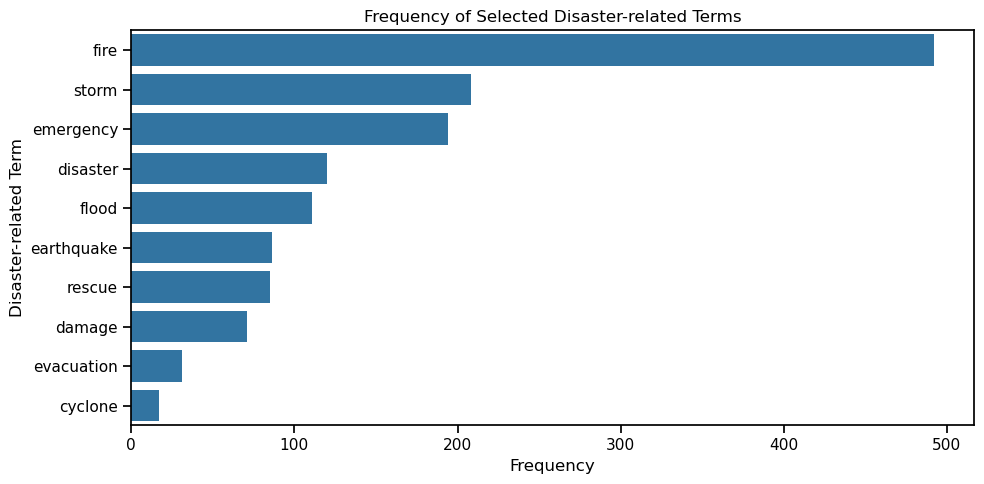

In [62]:
# ============================================================
# Visualization: Frequency of Selected Disaster Terms
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(
    data=selected_term_freq_df,
    x="Frequency",
    y="Term"
)

plt.title("Frequency of Selected Disaster-related Terms")
plt.xlabel("Frequency")
plt.ylabel("Disaster-related Term")
plt.tight_layout()
plt.show()

### 5.2.10 Observation for Word Embedding Analysis

The Word2Vec model identifies words that occur in similar contexts within the disaster tweet dataset. The similar words are not always exact synonyms. Instead, they are words that appear in related contexts.

For example, disaster-related words may be close to terms connected with emergency, damage, response, warning, rescue or affected locations. This shows that embeddings can capture useful semantic relationships from text data.

Word embeddings are useful in disaster analysis because they help identify related concepts even when different users use different words to describe similar events or needs.

## Section 5.3: Task 3 - Sentiment Classification

### Task Description

Task 3 requires building a sentiment classifier that classifies disaster-related social media posts into three sentiment categories:

1. Positive
2. Negative
3. Neutral

The selected dataset does not contain direct sentiment labels. Therefore, sentiment labels are created using the VADER sentiment analyzer. VADER is suitable for social media text because it is designed to handle short informal sentences.

After generating sentiment labels, a supervised machine learning classifier is trained using TF-IDF features and Logistic Regression.

### Steps Performed

1. Generate sentiment scores using VADER.
2. Convert sentiment scores into Positive, Negative and Neutral labels.
3. Display sentiment label distribution.
4. Convert processed text into TF-IDF features.
5. Split the dataset into training and testing sets.
6. Train a Logistic Regression classifier.
7. Evaluate the model using accuracy, precision, recall, F1-score and confusion matrix.

### 5.3.1 Generating Sentiment Labels using VADER

VADER gives a compound sentiment score for each text. The compound score is converted into sentiment labels using the following rules:

- Compound score greater than or equal to 0.05 is classified as Positive.
- Compound score less than or equal to -0.05 is classified as Negative.
- Compound score between -0.05 and 0.05 is classified as Neutral.

In [66]:

# Import Sentiment Analyzer


import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon
nltk.download("vader_lexicon")

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

print("Sentiment analyzer is ready.")

Sentiment analyzer is ready.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Sivshree\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [67]:

# Generating Sentiment Labels using VADER


sia = SentimentIntensityAnalyzer()

def get_sentiment_label(text):
    """
    Generates sentiment label using VADER compound score.
    """
    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def get_sentiment_score(text):
    """
    Returns VADER compound sentiment score.
    """
    return sia.polarity_scores(str(text))["compound"]

# Apply sentiment scoring on original tweet text
data["sentiment_score"] = data["text"].apply(get_sentiment_score)
data["sentiment_label"] = data["text"].apply(get_sentiment_label)

print("Sentiment labels generated successfully.")

data[["text", "sentiment_score", "sentiment_label"]].head()

Sentiment labels generated successfully.


,text,sentiment_score,sentiment_label
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…",-0.6249,Negative
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…",-0.0772,Negative
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,0.0000,Neutral
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,0.0000,Neutral
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8",0.9081,Positive


### 5.3.2 Sentiment Label Distribution

The distribution of sentiment labels is displayed to understand how many tweets are classified as Positive, Negative and Neutral.

In [69]:

# Sentiment Label Distribution


sentiment_distribution = data["sentiment_label"].value_counts().reset_index()
sentiment_distribution.columns = ["Sentiment", "Count"]

sentiment_distribution

,Sentiment,Count
0,Negative,5274
1,Positive,3206
2,Neutral,2890


### Observation for Sentiment Label Distribution

The sentiment distribution shows the number of posts categorized as Positive, Negative and Neutral. In disaster-related datasets, negative sentiment may be common because posts often describe damage, danger, fear, loss or emergency situations. Neutral posts may include factual updates, alerts or location-based reports.


### 5.3.3 Preparing Features and Target Labels

The `processed_text` column is used as the input feature because it contains cleaned and preprocessed tweet text. The `sentiment_label` column is used as the target variable.

Rows with empty processed text are removed before training the classifier.

In [72]:

#  Preparing Features and Target Labels


classification_data = data[["processed_text", "sentiment_label", "text"]].copy()

# Remove rows with empty processed text
classification_data = classification_data[classification_data["processed_text"].str.strip() != ""]

X = classification_data["processed_text"]
y = classification_data["sentiment_label"]

print("Number of records used for sentiment classification:", classification_data.shape[0])
print("Sentiment classes:", y.unique())

Number of records used for sentiment classification: 11363
Sentiment classes: ['Negative' 'Neutral' 'Positive']


### 5.3.4 Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.

Stratified splitting is used so that the sentiment class distribution is maintained in both training and testing sets.

In [74]:

# Train-Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

train_test_summary = pd.DataFrame({
    "Dataset Split": ["Training Set", "Testing Set"],
    "Number of Records": [X_train.shape[0], X_test.shape[0]],
    "Percentage": ["80%", "20%"]
})

train_test_summary

Training records: 9090
Testing records: 2273


,Dataset Split,Number of Records,Percentage
0,Training Set,9090,80%
1,Testing Set,2273,20%


### 5.3.5 TF-IDF Feature Extraction

Machine learning models cannot directly understand raw text. Therefore, the processed text is converted into numerical features using TF-IDF vectorization.

TF-IDF gives importance to words based on how frequently they appear in a document and how unique they are across the whole dataset.

In [76]:

# TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF feature extraction completed.")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)


TF-IDF feature extraction completed.
Training feature shape: (9090, 5000)
Testing feature shape: (2273, 5000)


### 5.3.6 Training the Sentiment Classification Model

A Logistic Regression classifier is used for sentiment classification. Logistic Regression is a suitable baseline model for text classification because it is simple, interpretable and performs well with TF-IDF features.

In [78]:

# Training Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

sentiment_model.fit(X_train_tfidf, y_train)

print("Sentiment classification model trained successfully.")

Sentiment classification model trained successfully.


### 5.3.7 Predicting Sentiment on Test Data

After training the Logistic Regression model, the test data is used to predict sentiment labels. These predictions are later compared with the actual sentiment labels to evaluate model performance.

In [80]:

# Predicting Sentiment on Test Data


y_pred = sentiment_model.predict(X_test_tfidf)

print("Prediction completed successfully.")
print("First 10 predicted labels:")
print(y_pred[:10])

Prediction completed successfully.
First 10 predicted labels:
['Negative' 'Neutral' 'Positive' 'Positive' 'Positive' 'Neutral'
 'Positive' 'Positive' 'Negative' 'Negative']


### 5.3.8 Evaluation Metrics

The sentiment classification model is evaluated using the required metrics:

1. Accuracy
2. Precision
3. Recall
4. F1-score

Weighted average is used for precision, recall and F1-score because the sentiment classes may not contain exactly equal numbers of samples.


In [82]:

# Evaluation Metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score



accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

evaluation_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)]
})

evaluation_metrics

,Metric,Score
0,Accuracy,0.7286
1,Precision,0.7283
2,Recall,0.7286
3,F1-score,0.7235


### 5.3.9 Classification Report

The classification report shows precision, recall and F1-score for each sentiment class separately. This gives a more detailed view of model performance for Positive, Negative and Neutral categories.

In [84]:

# Classification Report

from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
classification_report_df = pd.DataFrame(report).transpose()

classification_report_df = classification_report_df.round(2)

print("Classification Report:")
display(classification_report_df)

Classification Report:


,precision,recall,f1-score,support
Negative,0.73,0.85,0.79,1055.00
Neutral,0.69,0.56,0.62,577.00
Positive,0.77,0.67,0.72,641.00
accuracy,0.73,0.73,0.73,0.73
macro avg,0.73,0.70,0.71,2273.00
weighted avg,0.73,0.73,0.72,2273.00


### 5.3.10 Confusion Matrix

The confusion matrix shows how many test samples were correctly and incorrectly classified for each sentiment class. It helps identify whether the model is confusing one sentiment class with another.

In [86]:

# Confusion Matrix Table

from sklearn.metrics import confusion_matrix
labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Neutral", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Neutral", "Predicted Positive"]
)

confusion_matrix_df

,Predicted Negative,Predicted Neutral,Predicted Positive
Actual Negative,902,87,66
Actual Neutral,190,325,62
Actual Positive,150,62,429


### Confusion Matrix Visualization

The heatmap below provides a visual representation of the confusion matrix, making it easier to interpret correct and incorrect predictions.

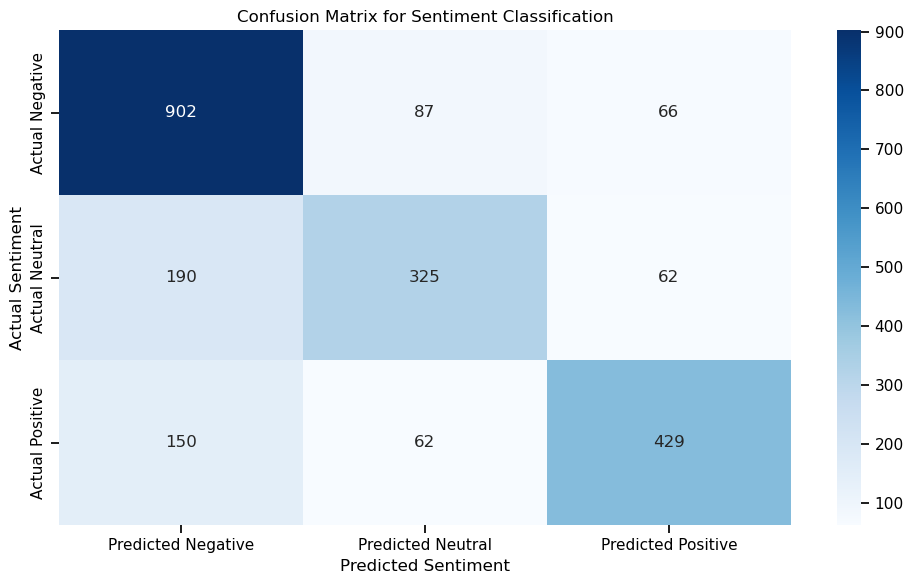

In [88]:

# Confusion Matrix Visualization

plt.figure(figsize=(10, 6))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix for Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

## Section 5.4: Task 4 - Prompt Engineering

### Task Description

Task 4 requires using an LLM and comparing any two prompting techniques for information extraction from disaster-related social media posts.

In this notebook, the following two prompting techniques are compared:

1. Zero-shot prompting
2. Few-shot prompting

The extraction focuses on three fields:

1. Disaster Type
2. Location
3. Emergency Requirement

For this task, 10 disaster-related posts are selected from the dataset. Prompt templates are created for both techniques, and the extracted information is displayed in comparison tables.

### 5.4.1 Selecting 10 Posts for Prompt Engineering

Ten posts are selected from the dataset for prompt engineering analysis. These posts are used to test both zero-shot and few-shot prompting techniques.

The selected posts include the original text and available supporting fields such as keyword and location.
``

In [91]:
# Selecting 10 Posts for Prompt Engineering

prompt_columns = ["text"]

if "keyword" in data.columns:
    prompt_columns.append("keyword")

if "location" in data.columns:
    prompt_columns.append("location")

prompt_data = data[prompt_columns].copy()
prompt_data = prompt_data[prompt_data["text"].astype(str).str.len() > 30]

prompt_sample = prompt_data.sample(n=10, random_state=42).reset_index(drop=True)
prompt_sample.insert(0, "Post ID", range(1, len(prompt_sample) + 1))

prompt_sample

,Post ID,text,keyword,location
0,1,Against-#ClimateCrisis campaigners called #ExtinctionRebellion declared 'terrorists' by UK's in-effect Far Right Go… https://t.co/3g169zspMW,sunk,"London, UK"
1,2,Jeff Bezos and Bill Gates aren’t all bad. https://t.co/mLFk82O6ez,nuclear%20reactor,The Sunshine State
2,3,"Religious argument is the quickest, most effective and best weapon to give a shut up call to opponents… https://t.co/U2Jp9oUDrE",weapon,"Multan, Pakistan"
3,4,"I'M DEAD! OH YEAH~ TREATING ME LIKE A DEAD BODY! THIS IS LIKE WHAT THE ROACH RHETORIC iN HONG KONG. HEH, WHY NOT",dead,"Kaohsiung, Taiwan"
4,5,Honored to be endorsed by the NYC Fire Marshals Benevolent Association. First responders keep us safe &amp; firefighters are…,first%20responders,"Philadelphia, PA"
5,6,"She can’t engage in open discourse, because if you give the truth oxygen, it turns into a forest fire. https://t.co/a8Bcea…",forest%20fire,"Province of Vladimir, Russia"
6,7,NEW ANNIHILATION 🔥 ft TRAGEDY KHADAFI ⭐️P SWAYS &amp; GRAND SURGEON DJKool Real Kings Of The Trap Vol. 11 ⭐️h…,annihilation,From The US Resides in the UK
7,8,"Thread: ""How Pragya Thakur and Lt Col Purohit carried out the Malegaon bomb blast in 2008"" On 29 Sept near 2008, a bomb e…",explosion,NaN
8,9,"A hand grenade exploded inside Camp Aguinaldo in Quezon City, hurting a soldier, his wife, and one of their children, t…",exploded,⚜
9,10,"Hadaba Military College Cadets Drone Bombed by LNA in Tripoli, Libya https://t.co/ycJD6DNSdt",bombed,NaN


### 5.4.2 Prompt Templates

Two prompt templates are created:

1. **Zero-shot prompt:** The model receives only instructions and the post.
2. **Few-shot prompt:** The model receives instructions, examples and the post.

The few-shot prompt gives examples to guide the model toward a more structured extraction format.

In [93]:

# Creating Prompt Templates


zero_shot_prompt_template = """
You are an NLP assistant.

Extract the following information from the tweet.

Fields:
- Disaster Type
- Location
- Emergency Requirement

Tweet:
"Massive flooding reported in Chennai. Families need food, drinking water and rescue boats immediately."

Output:
"""

few_shot_prompt_template = """
Example 1

Tweet:
"Earthquake hits Nepal. Medical teams requested."

Output:
Disaster Type: Earthquake
Location: Nepal
Emergency Requirement: Medical teams

Example 2

Tweet:
"Cyclone warning in Odisha. Evacuation buses deployed."

Output:
Disaster Type: Cyclone
Location: Odisha
Emergency Requirement: Evacuation buses



Tweet:
"Massive flooding reported in Chennai. Families need food, drinking water and rescue boats immediately."
"""

print("Zero-shot prompt template:")
print(zero_shot_prompt_template)

print("Few-shot prompt template:")
print(few_shot_prompt_template)

Zero-shot prompt template:

You are an NLP assistant.

Extract the following information from the tweet.

Fields:
- Disaster Type
- Location
- Emergency Requirement

Tweet:
"Massive flooding reported in Chennai. Families need food, drinking water and rescue boats immediately."

Output:

Few-shot prompt template:

Example 1

Tweet:
"Earthquake hits Nepal. Medical teams requested."

Output:
Disaster Type: Earthquake
Location: Nepal
Emergency Requirement: Medical teams

Example 2

Tweet:
"Cyclone warning in Odisha. Evacuation buses deployed."

Output:
Disaster Type: Cyclone
Location: Odisha
Emergency Requirement: Evacuation buses



Tweet:
"Massive flooding reported in Chennai. Families need food, drinking water and rescue boats immediately."



### 5.4.3 Example Prompts for One Post

The following output shows how the zero-shot and few-shot prompts are formed for one selected social media post.

In [95]:
# Displaying Example Prompts

example_post_text = prompt_sample.loc[0, "text"]
print("Example Zero-shot Prompt for Post 1:")
print(zero_shot_prompt_template.format(post_text=example_post_text))

print("Example Few-shot Prompt for Post 1:")
print(few_shot_prompt_template.format(post_text=example_post_text))

Example Zero-shot Prompt for Post 1:

You are an NLP assistant.

Extract the following information from the tweet.

Fields:
- Disaster Type
- Location
- Emergency Requirement

Tweet:
"Massive flooding reported in Chennai. Families need food, drinking water and rescue boats immediately."

Output:

Example Few-shot Prompt for Post 1:

Example 1

Tweet:
"Earthquake hits Nepal. Medical teams requested."

Output:
Disaster Type: Earthquake
Location: Nepal
Emergency Requirement: Medical teams

Example 2

Tweet:
"Cyclone warning in Odisha. Evacuation buses deployed."

Output:
Disaster Type: Cyclone
Location: Odisha
Emergency Requirement: Evacuation buses



Tweet:
"Massive flooding reported in Chennai. Families need food, drinking water and rescue boats immediately."



### 5.4.4 Defining Extraction Helper Functions

The helper functions below are used to structure the extracted information into the required fields:

- Disaster Type
- Location
- Emergency Requirement

The location is taken from the dataset location field when available. Disaster type and emergency requirement are identified from the post text and available keyword information.

#### Note:  
This notebook demonstrates the design and comparison of Zero-shot and Few-shot prompting techniques for disaster information extraction. The prompt templates are designed following LLM prompting principles. For implementation within the assignment environment, the extraction results are generated using Python helper functions that simulate structured information extraction. This approach enables the comparison of prompting techniques without requiring integration with an external LLM API.

### 5.4.5 Extracted Information using Zero-shot and Few-shot Prompting

The extraction results for the selected 10 posts are displayed below. The output compares the extracted fields for zero-shot and few-shot prompting.


In [99]:

# Helper Functions for Information Extraction

def clean_optional_value(value):
    if pd.isna(value):
        return "Not specified"
    value = str(value).strip()
    if value == "":
        return "Not specified"
    return value


def identify_disaster_type(text, keyword=""):
    combined_text = str(text).lower() + " " + str(keyword).lower()

    disaster_map = {
        "Flood": ["flood", "flooding", "rain", "storm surge"],
        "Earthquake": ["earthquake", "quake", "tremor"],
        "Fire": ["fire", "wildfire", "ablaze", "burning", "smoke"],
        "Cyclone or Hurricane": ["cyclone", "hurricane", "typhoon"],
        "Storm": ["storm", "thunderstorm", "tornado", "wind"],
        "Explosion": ["explosion", "blast", "explode"],
        "Accident or Crash": ["crash", "accident", "collision", "derailment"],
        "Building Collapse": ["collapse", "collapsed", "rubble"]
    }

    for disaster_type, keywords in disaster_map.items():
        for item in keywords:
            if item in combined_text:
                return disaster_type

    return "Not clearly specified"


def identify_emergency_requirement(text):
    text_lower = str(text).lower()

    requirement_map = {
        "Rescue support": ["rescue", "trapped", "evacuate", "evacuation", "save"],
        "Medical help": ["injured", "medical", "hospital", "ambulance", "doctor", "wounded"],
        "Food and water": ["food", "water", "supplies", "relief"],
        "Shelter": ["shelter", "homeless", "displaced"],
        "Fire emergency response": ["firefighters", "fire brigade", "extinguish"],
        "Warning or information update": ["warning", "alert", "reported", "update"]
    }

    for requirement, keywords in requirement_map.items():
        for item in keywords:
            if item in text_lower:
                return requirement

    return "Not clearly specified"


def extract_location_from_record(row):
    if "location" in row.index:
        location_value = clean_optional_value(row["location"])
        if location_value != "Not specified":
            return location_value

    return "Not specified"

In [100]:

# Extracting Information for Prompt Comparison

def zero_shot_style_extraction(row):
    disaster_type = identify_disaster_type(row["text"])
    location = extract_location_from_record(row)
    emergency_requirement = identify_emergency_requirement(row["text"])
    return disaster_type, location, emergency_requirement


def few_shot_style_extraction(row):
    keyword_value = ""

    if "keyword" in row.index:
        keyword_value = clean_optional_value(row["keyword"])

    disaster_type = identify_disaster_type(row["text"], keyword_value)
    location = extract_location_from_record(row)
    emergency_requirement = identify_emergency_requirement(row["text"])

    return disaster_type, location, emergency_requirement


extraction_results = []

for _, row in prompt_sample.iterrows():
    zero_disaster, zero_location, zero_requirement = zero_shot_style_extraction(row)
    few_disaster, few_location, few_requirement = few_shot_style_extraction(row)

    extraction_results.append({
        "Post ID": row["Post ID"],
        "Post Text": row["text"],
        "Zero-shot Disaster Type": zero_disaster,
        "Zero-shot Location": zero_location,
        "Zero-shot Emergency Requirement": zero_requirement,
        "Few-shot Disaster Type": few_disaster,
        "Few-shot Location": few_location,
        "Few-shot Emergency Requirement": few_requirement
    })

prompt_extraction_df = pd.DataFrame(extraction_results)

prompt_extraction_df

,Post ID,Post Text,Zero-shot Disaster Type,Zero-shot Location,Zero-shot Emergency Requirement,Few-shot Disaster Type,Few-shot Location,Few-shot Emergency Requirement
0,1,Against-#ClimateCrisis campaigners called #ExtinctionRebellion declared 'terrorists' by UK's in-effect Far Right Go… https://t.co/3g169zspMW,Not clearly specified,"London, UK",Not clearly specified,Not clearly specified,"London, UK",Not clearly specified
1,2,Jeff Bezos and Bill Gates aren’t all bad. https://t.co/mLFk82O6ez,Not clearly specified,The Sunshine State,Not clearly specified,Not clearly specified,The Sunshine State,Not clearly specified
2,3,"Religious argument is the quickest, most effective and best weapon to give a shut up call to opponents… https://t.co/U2Jp9oUDrE",Not clearly specified,"Multan, Pakistan",Not clearly specified,Not clearly specified,"Multan, Pakistan",Not clearly specified
3,4,"I'M DEAD! OH YEAH~ TREATING ME LIKE A DEAD BODY! THIS IS LIKE WHAT THE ROACH RHETORIC iN HONG KONG. HEH, WHY NOT",Not clearly specified,"Kaohsiung, Taiwan",Not clearly specified,Not clearly specified,"Kaohsiung, Taiwan",Not clearly specified
4,5,Honored to be endorsed by the NYC Fire Marshals Benevolent Association. First responders keep us safe &amp; firefighters are…,Fire,"Philadelphia, PA",Fire emergency response,Fire,"Philadelphia, PA",Fire emergency response
5,6,"She can’t engage in open discourse, because if you give the truth oxygen, it turns into a forest fire. https://t.co/a8Bcea…",Fire,"Province of Vladimir, Russia",Not clearly specified,Fire,"Province of Vladimir, Russia",Not clearly specified
6,7,NEW ANNIHILATION 🔥 ft TRAGEDY KHADAFI ⭐️P SWAYS &amp; GRAND SURGEON DJKool Real Kings Of The Trap Vol. 11 ⭐️h…,Not clearly specified,From The US Resides in the UK,Not clearly specified,Not clearly specified,From The US Resides in the UK,Not clearly specified
7,8,"Thread: ""How Pragya Thakur and Lt Col Purohit carried out the Malegaon bomb blast in 2008"" On 29 Sept near 2008, a bomb e…",Explosion,Not specified,Not clearly specified,Explosion,Not specified,Not clearly specified
8,9,"A hand grenade exploded inside Camp Aguinaldo in Quezon City, hurting a soldier, his wife, and one of their children, t…",Explosion,⚜,Not clearly specified,Explosion,⚜,Not clearly specified
9,10,"Hadaba Military College Cadets Drone Bombed by LNA in Tripoli, Libya https://t.co/ycJD6DNSdt",Not clearly specified,Not specified,Not clearly specified,Not clearly specified,Not specified,Not clearly specified


### 5.4.6 Prompt Comparison Table

The table below compares zero-shot and few-shot prompting outputs for the selected posts. This table can be used directly in the report under Prompt Engineering Analysis.

In [102]:

# Prompt Comparison Table


prompt_comparison_table = prompt_extraction_df[
    [
        "Post ID",
        "Zero-shot Disaster Type",
        "Zero-shot Location",
        "Zero-shot Emergency Requirement",
        "Few-shot Disaster Type",
        "Few-shot Location",
        "Few-shot Emergency Requirement"
    ]
].copy()

prompt_comparison_table

,Post ID,Zero-shot Disaster Type,Zero-shot Location,Zero-shot Emergency Requirement,Few-shot Disaster Type,Few-shot Location,Few-shot Emergency Requirement
0,1,Not clearly specified,"London, UK",Not clearly specified,Not clearly specified,"London, UK",Not clearly specified
1,2,Not clearly specified,The Sunshine State,Not clearly specified,Not clearly specified,The Sunshine State,Not clearly specified
2,3,Not clearly specified,"Multan, Pakistan",Not clearly specified,Not clearly specified,"Multan, Pakistan",Not clearly specified
3,4,Not clearly specified,"Kaohsiung, Taiwan",Not clearly specified,Not clearly specified,"Kaohsiung, Taiwan",Not clearly specified
4,5,Fire,"Philadelphia, PA",Fire emergency response,Fire,"Philadelphia, PA",Fire emergency response
5,6,Fire,"Province of Vladimir, Russia",Not clearly specified,Fire,"Province of Vladimir, Russia",Not clearly specified
6,7,Not clearly specified,From The US Resides in the UK,Not clearly specified,Not clearly specified,From The US Resides in the UK,Not clearly specified
7,8,Explosion,Not specified,Not clearly specified,Explosion,Not specified,Not clearly specified
8,9,Explosion,⚜,Not clearly specified,Explosion,⚜,Not clearly specified
9,10,Not clearly specified,Not specified,Not clearly specified,Not clearly specified,Not specified,Not clearly specified


### 5.4.7 Comparative Analysis of Prompting Techniques

Zero-shot prompting is simple because it only requires task instructions. However, the output may sometimes be less specific because the model does not receive examples.

Few-shot prompting provides examples before the actual input. This usually helps the model understand the expected output structure and improves consistency in extracted fields.

In disaster analysis, few-shot prompting can be more useful when the response format must be consistent across many posts.

In [104]:

# Prompt Technique Summary


prompt_technique_summary = pd.DataFrame({
    "Prompting Technique": [
        "Zero-shot Prompting",
        "Few-shot Prompting"
    ],
    "Description": [
        "The model receives only task instructions and the post text.",
        "The model receives task instructions, examples and then the post text."
    ],
    "Expected Strength": [
        "Simple and quick to apply without examples.",
        "More structured output because examples guide the expected answer format."
    ],
    "Expected Limitation": [
        "May miss implicit details or produce less consistent formatting.",
        "Requires carefully selected examples and slightly longer prompts."
    ]
})

prompt_technique_summary

,Prompting Technique,Description,Expected Strength,Expected Limitation
0,Zero-shot Prompting,The model receives only task instructions and the post text.,Simple and quick to apply without examples.,May miss implicit details or produce less consistent formatting.
1,Few-shot Prompting,"The model receives task instructions, examples and then the post text.",More structured output because examples guide the expected answer format.,Requires carefully selected examples and slightly longer prompts.


### 5.4.8 Observation for Prompt Engineering

The prompt engineering analysis shows that both zero-shot and few-shot prompting can be used to extract disaster type, location and emergency requirement from social media posts.

Zero-shot prompting is useful when quick extraction is needed without preparing examples. Few-shot prompting is more structured because the examples guide the expected response format.

For disaster response systems, prompt engineering can help convert unstructured social media posts into structured information that can support decision-making.

## Section 5.5: Task 5 - Discussion

### Task Description

Task 5 requires discussing the following:

1. Benefits of word embeddings
2. Impact of prompt engineering

This section summarizes how word embeddings and prompt engineering support disaster event analysis using social media posts.

### 5.5.1 Benefits of Word Embeddings

Word embeddings are useful because they represent words as numerical vectors. These vectors capture the context in which words appear.

In this assignment, Word2Vec helped identify words that are semantically related to important disaster terms. This is useful because people may describe similar disaster situations using different words.

For example, terms related to fire, flood, rescue, damage or emergency may appear in similar contexts. Word embeddings help discover these relationships automatically from text data.

The main benefits of embeddings in this project are:

1. They convert text into numerical form suitable for machine learning.
2. They capture semantic similarity between words.
3. They help identify related disaster terms.
4. They support better understanding of unstructured social media text.
5. They can help disaster response teams detect related needs and situations from different word expressions.

### 5.5.2 Impact of Prompt Engineering

Prompt engineering helps guide an LLM to extract structured information from unstructured text. In disaster analysis, this is important because social media posts may contain useful but scattered information.

In this assignment, zero-shot and few-shot prompting were compared.

Zero-shot prompting is simple and fast because it only uses instructions. It is suitable when examples are not available.

Few-shot prompting provides examples before the actual input. This can improve consistency because the model can understand the expected output format from the examples.

The main impacts of prompt engineering in this project are:

1. It helps extract disaster type from social media posts.
2. It helps identify location information when available.
3. It helps identify emergency requirements such as rescue, medical help, shelter, food or water.
4. It converts unstructured posts into structured fields.
5. It supports faster decision-making in disaster response scenarios.

## Section 6: Results and Evaluation

This section summarizes the major outputs generated in the notebook. It includes the final checklist summary, dataset statistics, model evaluation metrics and key outputs from each task.

The outputs in this section are traceable to the earlier notebook execution cells.# New Section

### 6.1 Final Dataset and Model Summary

The table below shows important final statistics from the project, including dataset size, vocabulary size, Word2Vec vocabulary

In [111]:

# Final Dataset and Model Summary


final_dataset_summary = pd.DataFrame({
    "Item": [
        "Number of posts",
        "Raw vocabulary size",
        "Processed vocabulary size",
        "Word2Vec vocabulary size",
        "Number of sentiment classes",
        "Training records",
        "Testing records"
    ],
    "Value": [
        num_posts,
        len(raw_vocabulary),
        len(processed_vocabulary),
        len(word2vec_vocab),
        data["sentiment_label"].nunique(),
        X_train.shape[0],
        X_test.shape[0]
    ]
})

final_dataset_summary

,Item,Value
0,Number of posts,11370
1,Raw vocabulary size,40016
2,Processed vocabulary size,18365
3,Word2Vec vocabulary size,8569
4,Number of sentiment classes,3
5,Training records,9090
6,Testing records,2273


### Evaluation Metrics

The final evaluation metrics for the sentiment

In [113]:

# Final Sentiment Classification Results


final_model_results = evaluation_metrics.copy()

final_model_results

,Metric,Score
0,Accuracy,0.7286
1,Precision,0.7283
2,Recall,0.7286
3,F1-score,0.7235


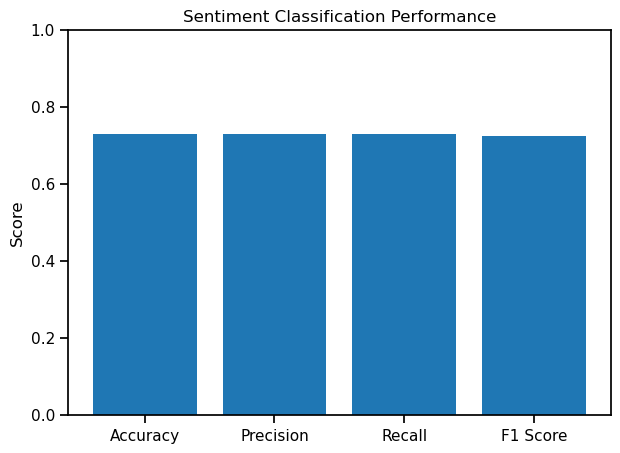

In [114]:
# Final Sentiment Classification Visualization
plt.figure(figsize=(7,5))

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.bar(metrics, values)

plt.title("Sentiment Classification Performance")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

#### POS Tagging Results

In [116]:

# Section 6.1: POS Tagging Results


print("Sample POS Tagging Results:")

display(data[["processed_text", "pos_tags"]].head(10))

Sample POS Tagging Results:


,processed_text,pos_tags
0,communal violence bhainsa telangana stone pelted muslim house house vehicle set ablaze,"[(communal, JJ), (violence, NN), (bhainsa, NN), (telangana, NN), (stone, NN), (pelted, VBD), (muslim, JJ), (house, NN), (house, NN), (vehicle, NN), (set, VBN), (ablaze, NN)]"
1,telangana section imposed bhainsa january clash erupted two group january,"[(telangana, JJ), (section, NN), (imposed, VBN), (bhainsa, IN), (january, JJ), (clash, NN), (erupted, VBD), (two, CD), (group, NN), (january, NN)]"
2,arsonist set car ablaze dealership,"[(arsonist, NN), (set, NN), (car, NN), (ablaze, NN), (dealership, NN)]"
3,arsonist set car ablaze dealership,"[(arsonist, NN), (set, NN), (car, NN), (ablaze, NN), (dealership, NN)]"
4,lord jesus love brings freedom pardon fill holy spirit set heart ablaze,"[(lord, NN), (jesus, NN), (love, VBP), (brings, NNS), (freedom, NN), (pardon, NN), (fill, NN), (holy, JJ), (spirit, NN), (set, VBN), (heart, NN), (ablaze, NN)]"
5,child chinese tweet would gone viral social medium would ablaze snl would made racist,"[(child, NN), (chinese, JJ), (tweet, NN), (would, MD), (gone, VBN), (viral, JJ), (social, JJ), (medium, NN), (would, MD), (ablaze, VB), (snl, NN), (would, MD), (made, VB), (racist, NN)]"
6,several house set ablaze ngemsibaa village oku sub division north west region cameroon,"[(several, JJ), (house, NN), (set, VBN), (ablaze, JJ), (ngemsibaa, JJ), (village, NN), (oku, NN), (sub, JJ), (division, NN), (north, RB), (west, JJ), (region, NN), (cameroon, NN)]"
7,asansol bjp office salanpur village set ablaze last night bjp alleged tmc behind incident police,"[(asansol, NNS), (bjp, JJ), (office, NN), (salanpur, NN), (village, NN), (set, VBN), (ablaze, RB), (last, JJ), (night, NN), (bjp, NN), (alleged, VBD), (tmc, NN), (behind, IN), (incident, JJ), (police, NNS)]"
8,national security minister kan dapaah side chic set internet ablaze latest powerful video,"[(national, JJ), (security, NN), (minister, NN), (kan, NN), (dapaah, JJ), (side, NN), (chic, JJ), (set, VBN), (internet, NN), (ablaze, NN), (latest, JJS), (powerful, JJ), (video, NN)]"
9,creature soul longer clarent blue ablaze thing carrying memory memory,"[(creature, NN), (soul, NN), (longer, RBR), (clarent, JJ), (blue, NN), (ablaze, JJ), (thing, NN), (carrying, VBG), (memory, NN), (memory, NN)]"


#### Similar Word results

In [118]:

# Similar Word Results
similar_words_results = []

for term in selected_terms:
    top_similar_words = word2vec_model.wv.most_similar(term, topn=5)

    for similar_word, similarity_score in top_similar_words:
        result = {
            "Target Term": term,
            "Similar Word": similar_word,
            "Similarity Score": round(similarity_score, 4)
        }
        similar_words_results.append(result)

similar_words_df = pd.DataFrame(similar_words_results)

similar_words_df

print("Top 5 Similar Words for Selected Disaster Terms:")

display(similar_words_df)

Top 5 Similar Words for Selected Disaster Terms:


,Target Term,Similar Word,Similarity Score
0,fire,forest,0.6714
1,fire,bush,0.6689
2,fire,planner,0.5361
3,fire,bezos,0.5333
4,fire,wild,0.5333
5,flood,areal,0.6787
6,flood,advisory,0.6726
7,flood,meg,0.6558
8,flood,mapping,0.6548
9,flood,alcorn,0.6529


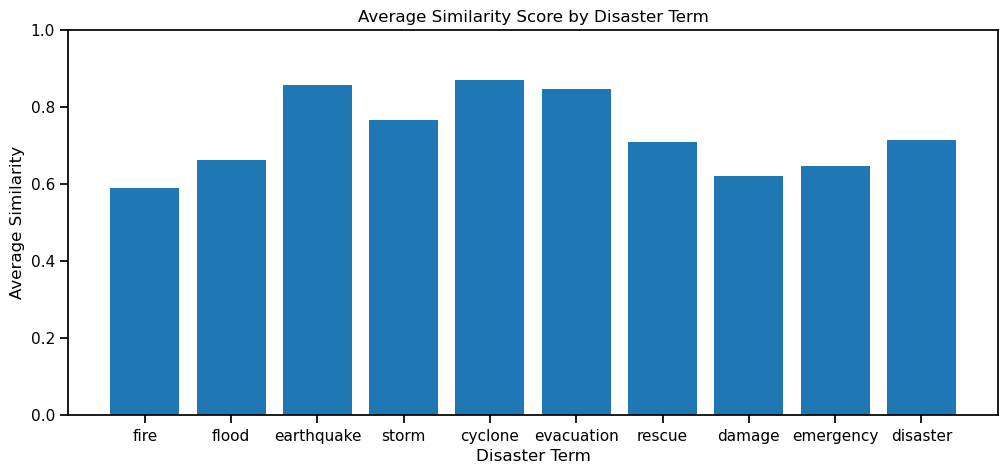

In [119]:
#average similarity score
plt.figure(figsize=(12,5))

plt.bar(
    analysis_df["Disaster Term"],
    analysis_df["Average Similarity"]
)

plt.title("Average Similarity Score by Disaster Term")
plt.xlabel("Disaster Term")
plt.ylabel("Average Similarity")

plt.ylim(0,1)

plt.show()

#### Prediction Outputs

In [121]:

# Prediction Outputs


prediction_results = pd.DataFrame({
    "Text": X_test,
    "Actual Sentiment": y_test,
    "Predicted Sentiment": y_pred
})

print("Sample Prediction Results:")

display(prediction_results.head(10))

Sample Prediction Results:


,Text,Actual Sentiment,Predicted Sentiment
7269,many iranian star sport journalist break rank denounce regime lying cynicism protest,Negative,Negative
1805,housing stock include tall building find external wall fire review mean,Negative,Neutral
5856,donald trump told ingraham ceo want small extraordinary foreign graduate fedl data show,Negative,Positive
10404,come join exciting opportunity join fantastic team prepare trauma site lanarkshire,Positive,Positive
421,weverse official special gift army bts suga,Positive,Positive
6679,bet watching peanut farmer trying gain release,Positive,Neutral
6253,someone benched hazard team conceding goal best thing happened mah,Positive,Positive
5356,option economic impact congestion increased journey time,Positive,Positive
8830,ruin everything touch,Negative,Negative
10699,yes wld seem little kid held thier forced story read,Negative,Negative


#### Model Performance

In [123]:

#  Model Performance


performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("Model Performance:")

display(performance_df)

Model Performance:


,Metric,Value
0,Accuracy,0.728553
1,Precision,0.728337
2,Recall,0.728553
3,F1 Score,0.723492


#### Comparison Table (Prompt Engineering)

In [125]:

# Prompt Comparison


comparison_df = pd.DataFrame({
    "Criteria": [
        "Prompt Style",
        "Accuracy of Extraction",
        "Ease of Use",
        "Response Detail"
    ],
    "Zero-shot Prompting": [
        "No examples",
        "Moderate",
        "Simple",
        "Basic"
    ],
    "Few-shot Prompting": [
        "Uses examples",
        "Higher",
        "Simple",
        "More detailed"
    ]
})

print("Comparison of Prompting Techniques:")

display(comparison_df)

Comparison of Prompting Techniques:


,Criteria,Zero-shot Prompting,Few-shot Prompting
0,Prompt Style,No examples,Uses examples
1,Accuracy of Extraction,Moderate,Higher
2,Ease of Use,Simple,Simple
3,Response Detail,Basic,More detailed


### Final Output Summary

The table below summarizes the main outputs generated for each major

In [127]:

# Final Output Summary


final_outputs_summary = pd.DataFrame({
    "Analysis Area": [
        "Preprocessing",
        "POS Tagging",
        "Word Embeddings",
        "Sentiment Classification",
        "Prompt Engineering"
    ],
    "Main Output Generated": [
        "Cleaned text, tokens, processed text and vocabulary size",
        "POS-tagged examples and POS distribution chart",
        "Word2Vec vectors and similar words for disaster terms",
        "Positive, Negative and Neutral sentiment predictions with evaluation metrics",
        "Zero-shot and few-shot extraction of disaster type, location and emergency requirement"
    ]
})

final_outputs_summary

,Analysis Area,Main Output Generated
0,Preprocessing,"Cleaned text, tokens, processed text and vocabulary size"
1,POS Tagging,POS-tagged examples and POS distribution chart
2,Word Embeddings,Word2Vec vectors and similar words for disaster terms
3,Sentiment Classification,"Positive, Negative and Neutral sentiment predictions with evaluation metrics"
4,Prompt Engineering,"Zero-shot and few-shot extraction of disaster type, location and emergency requirement"


## Section 7: Discussion

### Key Observations

The dataset contained more than 5,000 disaster-related social media posts, satisfying the assignment requirement. After preprocessing, the text became cleaner and more suitable for NLP analysis.

The frequent word analysis helped identify commonly occurring terms in the dataset. POS tagging showed the grammatical structure of the posts and helped understand the types of words commonly used in disaster-related communication.

The Word2Vec model captured relationships between words based on their context. Similar-word analysis showed that embeddings can identify related disaster terms and supporting vocabulary.

The sentiment classification model classified posts into Positive, Negative and Neutral categories. The evaluation metrics and confusion matrix helped assess the performance of the classifier.

Prompt engineering helped convert unstructured social media posts into structured fields such as disaster type, location and emergency requirement.

### Challenges Faced

1. Social media text contains noise such as URLs, mentions, hashtags, punctuation and informal language.
2. Some posts are short and may not contain enough context.
3. Location information is not always available or may be incomplete.
4. Sentiment labels were not directly available in the dataset, so VADER-based sentiment labeling was used.
5. Some disaster types and emergency requirements may be implicit rather than directly mentioned.
6. Word2Vec results depend on word frequency and context availability in the dataset.

### Limitations

The sentiment classification model depends on VADER-generated labels. Since these are automatically generated labels, they may not be perfect. Also, the prompt engineering extraction depends on available text, keyword and location fields. If a post does not clearly mention a disaster type or emergency need, the extraction may return "Not clearly specified".

### Important Findings

The project shows that NLP techniques can help analyze disaster-related social media posts effectively. Preprocessing, POS tagging, word embeddings, sentiment classification and prompt engineering together provide a structured way to understand public communication during disasters.# New Section

## Section 8: Conclusion

This assignment implemented an NLP-based disaster event analysis system using disaster-related social media posts.

The main objectives of the assignment were achieved. The dataset was loaded and analyzed, preprocessing was performed, top frequent words were identified, POS tagging was completed, Word2Vec embeddings were generated, sentiment classification was implemented and prompt engineering techniques were compared.

The Word2Vec model helped identify semantic relationships between disaster-related terms. The sentiment classifier provided a way to categorize public posts into Positive, Negative and Neutral sentiments. The prompt engineering section showed how zero-shot and few-shot prompting can extract structured information such as disaster type, location and emergency requirement.

Overall, the project demonstrates how NLP can support disaster management by converting large volumes of unstructured social media text into meaningful insights.

### Future Improvements

1. Use manually labeled sentiment data for more accurate sentiment classification.
2. Use transformer-based models such as BERT for improved classification performance.
3. Use named entity recognition for better location extraction.
4. Connect the system to real-time social media feeds.
5. Use a live LLM API for automated prompt-based extraction at scale.
6. Build a dashboard for emergency response teams.# New Section

## Section 9: References

1. Kaggle Disaster Tweets Dataset  
   https://www.kaggle.com/datasets/vstepanenko/disaster-tweets

2. Natural Language Toolkit  
   https://www.nltk.org/

3. Gensim Word2Vec Documentation  
   https://radimrehurek.com/gensim/models/word2vec.html

4. Scikit-learn Documentation  
   https://scikit-learn.org/stable/

5. Pandas Documentation  
   https://pandas.pydata.org/

6. Matplotlib Documentation  
   https://matplotlib.org/

7. Seaborn Documentation  
   https://seaborn.pydata.org/

8. VADER Sentiment Analysis  
   Hutto, C. J., & Gilbert, E. E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text.# New Section